# **Project UAS ADTT Kelompok 8**
**Enggar Respati (23031030011)**  
**Muhammad Roihan Ash Shiddieqy (23031030030)**

# **IMPORT LIBRARY**

In [ ]:
!pip install Sastrawi
!pip install wordcloud
!pip install swifter
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from nltk.corpus import stopwords
from nltk.tokenize import RegexpTokenizer
from nltk.util import ngrams
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, accuracy_score,
                              confusion_matrix, ConfusionMatrixDisplay)
from imblearn.over_sampling import SMOTE
from wordcloud import WordCloud
from collections import Counter
from google.colab import files
import nltk
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import re
import pandas as pd
import numpy as np
import string
import swifter
nltk.download('stopwords')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 8.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 33.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for swifter: filename=swifter-1.4.0-py3-none-any.whl size=16505 sha256=989b42158e7299fc507b919a647ec7238c99eca5fa83cebc603e9369339e4f85
  Stored in directory: /root/.cache/pip/wheels/d9/31/ff/ff51141a088571a9f672449e5aad5ea8bb35ca5d95ba135f30
Successfully built swifter


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

# **LOAD DATASET**

In [ ]:
uploaded = files.upload()

file_name = list(uploaded.keys())[0]
reviews_rp = pd.read_csv(file_name)
display(reviews_rp.head())

Saving reviews_rp.csv to reviews_rp.csv


,x1i10hfl href,xpdipgo src,_ap3a,x1i10hfl href 3,x1ejq31n,x1lliihq 2,x1lliihq 3,x1lliihq 4
0,https://www.instagram.com/dj_donny/,https://scontent.cdninstagram.com/v/t51.82787-...,dj_donny,https://www.instagram.com/p/DYY4wB5j0kv/c/1809...,2d,NAUZUBILAMINZALIK! PRESIDEN NGOMONG GINI!,"29,494 likes",Reply
1,https://www.instagram.com/fazriandikaaa/,https://scontent.cdninstagram.com/v/t51.82787-...,fazriandikaaa,https://www.instagram.com/p/DYY4wB5j0kv/c/1812...,2d,"BERKALI-KALI GAGAL MENANG, SEKALI NYA MENANG E...","10,804 likes",Reply
2,https://www.instagram.com/ansori.firman/,https://scontent.cdninstagram.com/v/t51.82787-...,ansori.firman,https://www.instagram.com/p/DYY4wB5j0kv/c/1786...,2d,Izroil tolong jemput orang itu,"5,788 likes",Reply
3,https://www.instagram.com/nana.mariana_20/,https://scontent.cdninstagram.com/v/t51.82787-...,nana.mariana_20,https://www.instagram.com/p/DYY4wB5j0kv/c/1788...,1d,Bangga jd anak abah ❤️,100 likes,Reply
4,https://www.instagram.com/priskilaoktavianii/,https://scontent.cdninstagram.com/v/t51.82787-...,priskilaoktavianii,https://www.instagram.com/p/DYY4wB5j0kv/c/1816...,1d,Orang desa transaksinya pake diamond mobile le...,376 likes,Reply


# **PREPROCESSING**

## **Data Cleaning**

In [ ]:
reviews_rp = reviews_rp.rename(columns={
    '_ap3a'       : 'username',
    'x1lliihq 2'  : 'text',
    'x1lliihq 3'  : 'likes'
})

In [ ]:
reviews_rp = reviews_rp[['username', 'text', 'likes']]                  # Pilih kolom
reviews_rp = reviews_rp.dropna(subset=['text'])                         # Drop NaN
reviews_rp = reviews_rp[reviews_rp['text'].str.strip() != '']           # Drop string kosong
reviews_rp = reviews_rp[reviews_rp['text'].str.split().str.len() >= 3]  # Filter teks pendek
reviews_rp = reviews_rp.drop_duplicates(subset=['text'])                # Hapus duplikat
reviews_rp = reviews_rp.reset_index(drop=True)

In [ ]:
reviews_rp.shape

(2367, 3)

In [ ]:
reviews_rp.isnull().sum()

,0
username,0
text,0
likes,0


In [ ]:
reviews_rp.duplicated(subset=['text']).sum()

np.int64(0)

## **Cleaning Text**
Mengubah text menjadi lower case, menghapus tanda baca, angka, karakter khusus, dan karakter lain sehingga text dapat lebih mudah dipahami oleh mesin

In [ ]:
def clean_text(text):

    text = str(text)

    text = re.sub(r'@[^\s]+', '', text)              # hapus mention
    text = re.sub(r'http\S+|www\S+', '', text)       # hapus URL
    text = re.sub(r'\d+', '', text)                  # hapus angka
    text = re.sub(r'<.*?>', '', text)                # hapus HTML
    text = re.sub(r'[^\w\s]', ' ', text)             # hapus punctuation/emoji
    text = re.sub(r'[^a-zA-Z\s]', '', text)          # hanya huruf dan spasi
    text = re.sub(r'\n', ' ', text)                  # hapus newline
    text = re.sub(r'\bnya\b', '', text)              # hapus kata 'nya'
    text = re.sub(r'\b[a-zA-Z]\b', ' ', text)        # hapus huruf tunggal
    text = re.sub(r"([a-zA-Z])\1{2,}", r"\1", text)  # normalisasi huruf berulang
    text = text.lower()                              # Case Folding
    re.sub(r"\s+", " ", text).strip()                # rapikan spasi
    return text

reviews_rp['clean'] = reviews_rp['text'].apply(clean_text)

# Setelah clean_text():
reviews_rp['clean'] = reviews_rp['text'].apply(clean_text)
reviews_rp = reviews_rp[reviews_rp['clean'].str.strip() != '']          # Drop hasil cleaning kosong
reviews_rp = reviews_rp[reviews_rp['clean'].str.split().str.len() >= 2]
reviews_rp = reviews_rp.reset_index(drop=True)

display(reviews_rp[['text', 'clean']].head(5))

,text,clean
0,NAUZUBILAMINZALIK! PRESIDEN NGOMONG GINI!,nauzubilaminzalik presiden ngomong gini
1,"BERKALI-KALI GAGAL MENANG, SEKALI NYA MENANG E...",berkali kali gagal menang sekali nya menang e...
2,Izroil tolong jemput orang itu,izroil tolong jemput orang itu
3,Bangga jd anak abah ❤️,bangga jd anak abah
4,Orang desa transaksinya pake diamond mobile le...,orang desa transaksinya pake diamond mobile le...


## **Tokenisasi**

In [ ]:
regexp = RegexpTokenizer(r'\w+')
reviews_rp['token'] = reviews_rp['clean'].apply(regexp.tokenize)
reviews_rp[["clean", "token"]].head(5)

,clean,token
0,nauzubilaminzalik presiden ngomong gini,"[nauzubilaminzalik, presiden, ngomong, gini]"
1,berkali kali gagal menang sekali nya menang e...,"[berkali, kali, gagal, menang, sekali, nya, me..."
2,izroil tolong jemput orang itu,"[izroil, tolong, jemput, orang, itu]"
3,bangga jd anak abah,"[bangga, jd, anak, abah]"
4,orang desa transaksinya pake diamond mobile le...,"[orang, desa, transaksinya, pake, diamond, mob..."


## **Normalisasi**

In [ ]:
normalized_word_dict = {
    "bgt": "banget",
    "yg": "yang",
    "gk": "tidak",
    "ga": "tidak",
    "gak": "tidak",
    "nggak": "tidak",
    "tdk": "tidak",
    "kalo": "kalau",
    "kl": "kalau",
    "pake": "pakai",
    "pk": "pakai",
    "smpe": "sampai",
    "smpai": "sampai",
    "jd": "jadi",
    "jdi": "jadi",
    "utk": "untuk",
    "dr": "dari",
    "krn": "karena",
    "karna": "karena",
    "trs": "terus",
    "trus": "terus",
    "dgn": "dengan",
    "blm": "belum",
    "udh": "sudah",
    "sdh": "sudah",
    "aja": "saja",
    "doang": "saja",
    "aj": "saja",
    "org": "orang",
    "tmn": "teman",
    "temen": "teman",
    "bnr": "benar",
    "bnr": "benar",
    "mantul": "mantap betul",
    "btw": "ngomong-ngomong",
    "lol": "lucu",
    "wkwk": "tertawa",
    "wkwwk": "tertawa",
    "hehe": "tertawa",
    "xixi": "tertawa",
    "cm": "cuma",
    "cmn": "cuma",
    "tp": "tetapi",
    "tpi": "tetapi",
    "dlm": "dalam",
    "jg": "juga",
    "sy": "saya",
    "gw": "saya",
    "gue": "saya",
    "akuh": "aku",
    "aq": "aku",
    "km": "kamu",
    "lu": "kamu",
    "loe": "kamu",
    "bgtu": "begitu",
    "gitu": "begitu",
    "gni": "begini",
    "gin": "begini",
    "gini": "begini",
    "asbun": "asal bunyi",
    "ngasbun": "mengasal bunyi",
    "mkn": "makan",
    "minum2": "minum-minum",
    "pdhl": "padahal",
    "dpt": "dapat",
    "bsa": "bisa",
    "bs": "bisa",
    "cape": "capek",
    "capee": "capek",
    "bgus": "bagus",
    "jele": "jelek",
    "makasih": "terima kasih",
    "thx": "terima kasih",
    "makasi": "terima kasih",
    "sippp": "sip",
    "okk": "oke",
    "okey": "oke",
    "udhhlah": "sudahlah"
}
def normalized_term(tokens):
    return [normalized_word_dict.get(term, term) for term in tokens]

reviews_rp['normalisasi'] = reviews_rp['token'].apply(normalized_term)
display(reviews_rp[['token', 'normalisasi']].head(5))

,token,normalisasi
0,"[nauzubilaminzalik, presiden, ngomong, gini]","[nauzubilaminzalik, presiden, ngomong, begini]"
1,"[berkali, kali, gagal, menang, sekali, nya, me...","[berkali, kali, gagal, menang, sekali, nya, me..."
2,"[izroil, tolong, jemput, orang, itu]","[izroil, tolong, jemput, orang, itu]"
3,"[bangga, jd, anak, abah]","[bangga, jadi, anak, abah]"
4,"[orang, desa, transaksinya, pake, diamond, mob...","[orang, desa, transaksinya, pakai, diamond, mo..."


## **Stopwords Removal**
Menghapus kata hubung maupun kata yang kurang bermakna pada text

In [ ]:
stopwords_id = set(stopwords.words('indonesian'))
additional_stopwords = {
    "utk","yg","nya","aja","ga","gk","kalo", "gak",
    "nih","sih","dong","deh","lah","pun", "saad", "bgt",
    "dan", "isi", "kayak", "ya", "si", "tp", "moga", "dg","dr",
    "klo", "pake", "rb", "dar", "sy", "lg", "bs", "jg", "krn", "tdk",
    "yuk", "hm", "eh", "ah", "oh", "wah", "oke", "gas"
}

stopwords_id = stopwords_id.union(additional_stopwords)

def remove_stopwords(tokens):
    return [w for w in tokens if w not in stopwords_id]

reviews_rp['stopwords'] = reviews_rp['normalisasi'].apply(remove_stopwords)
display(reviews_rp[['normalisasi', 'stopwords']].head(5))

,normalisasi,stopwords
0,"[nauzubilaminzalik, presiden, ngomong, begini]","[nauzubilaminzalik, presiden, ngomong]"
1,"[berkali, kali, gagal, menang, sekali, nya, me...","[berkali, kali, gagal, menang, menang, gagal]"
2,"[izroil, tolong, jemput, orang, itu]","[izroil, tolong, jemput, orang]"
3,"[bangga, jadi, anak, abah]","[bangga, anak, abah]"
4,"[orang, desa, transaksinya, pakai, diamond, mo...","[orang, desa, transaksinya, pakai, diamond, mo..."


## **Stemming**

In [ ]:
factory = StemmerFactory()
stemmer = factory.create_stemmer()

term_dict = {}
for doc in reviews_rp['stopwords']:
    for term in doc:
        if term not in term_dict:
            term_dict[term] = stemmer.stem(term)

def get_stemmed_term(doc):
    return [term_dict[term] for term in doc]

reviews_rp['stemmer'] = reviews_rp['stopwords'].apply(get_stemmed_term)
reviews_rp['final']   = reviews_rp['stemmer'].apply(lambda x: " ".join(x))

display(reviews_rp[['stopwords', 'stemmer', 'final']].head(5))


,stopwords,stemmer,final
0,"[nauzubilaminzalik, presiden, ngomong]","[nauzubilaminzalik, presiden, ngomong]",nauzubilaminzalik presiden ngomong
1,"[berkali, kali, gagal, menang, menang, gagal]","[kali, kali, gagal, menang, menang, gagal]",kali kali gagal menang menang gagal
2,"[izroil, tolong, jemput, orang]","[izroil, tolong, jemput, orang]",izroil tolong jemput orang
3,"[bangga, anak, abah]","[bangga, anak, abah]",bangga anak abah
4,"[orang, desa, transaksinya, pakai, diamond, mo...","[orang, desa, transaksi, pakai, diamond, mobil...",orang desa transaksi pakai diamond mobile legend


## **Labeling Data**

### **Labeling Sentimen dengan InSet Lexicon (Sintaks yang Benar)**

Fungsi `label_sentiment_inset` ini menggunakan kamus sentimen `pos_dict` dan `neg_dict` yang dimuat dari file InSet (`positive.tsv` dan `negative.tsv`). Setiap kata dalam teks akan diperiksa di kamus ini. Jika kata ditemukan di kamus positif, bobotnya akan ditambahkan ke skor total. Jika ditemukan di kamus negatif, bobot absolutnya akan dikurangi dari skor total.

Akhirnya, skor total akan menentukan sentimen:
- Skor > 0: 'positif'
- Skor < 0: 'negatif'
- Skor = 0: 'netral'

Ini adalah cara yang benar untuk menerapkan pelabelan sentimen berbasis leksikon dengan InSet, memastikan bobot numerik digunakan secara akurat.

In [ ]:
# Definisikan ulang fungsi label_sentiment_inset untuk demonstrasi 'sintaks yang benar'
import urllib.request
import pandas as pd

url_pos = "https://raw.githubusercontent.com/fajri91/InSet/master/positive.tsv"
url_neg = "https://raw.githubusercontent.com/fajri91/InSet/master/negative.tsv"

urllib.request.urlretrieve(url_pos, "positive.tsv")
urllib.request.urlretrieve(url_neg, "negative.tsv")

# Correctly read the CSV files, assuming they have a header, and convert 'weight' to int
df_pos = pd.read_csv("positive.tsv", sep='\t', dtype={'weight': int})
df_neg = pd.read_csv("negative.tsv", sep='\t', dtype={'weight': int})

# Buat dict dengan bobot
pos_dict = dict(zip(df_pos['word'], df_pos['weight']))
neg_dict = dict(zip(df_neg['word'], df_neg['weight']))

def label_sentiment_inset(text):
    words = str(text).split()
    score = 0
    for word in words:
        if word in pos_dict:
            score += pos_dict[word]
        if word in neg_dict:
            score -= abs(neg_dict[word])

    if score > 0:
        return 'positif'
    elif score < 0:
        return 'negatif'
    else:
        return 'netral'

# Terapkan kembali fungsi ke kolom 'final' untuk mendapatkan sentimen
reviews_rp['sentimen_inset'] = reviews_rp['final'].apply(label_sentiment_inset)

print("\nDistribusi Sentimen (menggunakan InSet Lexicon):")
print(reviews_rp['sentimen_inset'].value_counts())
display(reviews_rp[['final', 'sentimen_inset']].head(10))


Distribusi Sentimen (menggunakan InSet Lexicon):
sentimen_inset
negatif    1059
positif     700
netral      599
Name: count, dtype: int64


,final,sentimen_inset
0,nauzubilaminzalik presiden ngomong,positif
1,kali kali gagal menang menang gagal,negatif
2,izroil tolong jemput orang,positif
3,bangga anak abah,positif
4,orang desa transaksi pakai diamond mobile legend,positif
5,cocok pimpin,positif
6,asbunnya asal bunyi banget,positif
7,warga desa lereng gunung sindoro liat dollar h...,negatif
8,nyindir,netral
9,warga desa mgkn pakai dolar makan tempe kedela...,negatif


### **Pembuatan Label Numerik yang Lebih Realistis dari InSet Lexicon**

Setelah menerapkan pelabelan sentimen menggunakan InSet Lexicon, sekarang kita akan membuat label numerik yang sesuai (`label_inset`). Ini akan digunakan untuk analisis dan pemodelan selanjutnya, yang akan memberikan representasi sentimen yang lebih realistis dibandingkan dengan label sebelumnya yang mungkin menggunakan kamus kata yang lebih sederhana.

In [ ]:
# Buat pemetaan label untuk InSet
label_map_inset = {'positif': 2, 'netral': 1, 'negatif': 0}

# Terapkan pemetaan ke kolom 'sentimen_inset' untuk mendapatkan label numerik yang baru
reviews_rp['label_inset'] = reviews_rp['sentimen_inset'].map(label_map_inset)

print("\nDistribusi Label Numerik (berdasarkan InSet Lexicon):")
print(reviews_rp['label_inset'].value_counts())
display(reviews_rp[['final', 'sentimen_inset', 'label_inset']].head(10))

# Memperbarui kolom 'label' yang akan digunakan untuk pemodelan agar lebih 'realistis'
# dengan menggunakan hasil dari InSet Lexicon.
reviews_rp['label'] = reviews_rp['label_inset']

print("\nDistribusi Kolom 'label' yang Diperbarui (menggunakan InSet Lexicon):")
print(reviews_rp['label_inset'].value_counts())


Distribusi Label Numerik (berdasarkan InSet Lexicon):
label_inset
0    1059
2     700
1     599
Name: count, dtype: int64


,final,sentimen_inset,label_inset
0,nauzubilaminzalik presiden ngomong,positif,2
1,kali kali gagal menang menang gagal,negatif,0
2,izroil tolong jemput orang,positif,2
3,bangga anak abah,positif,2
4,orang desa transaksi pakai diamond mobile legend,positif,2
5,cocok pimpin,positif,2
6,asbunnya asal bunyi banget,positif,2
7,warga desa lereng gunung sindoro liat dollar h...,negatif,0
8,nyindir,netral,1
9,warga desa mgkn pakai dolar makan tempe kedela...,negatif,0



Distribusi Kolom 'label' yang Diperbarui (menggunakan InSet Lexicon):
label_inset
0    1059
2     700
1     599
Name: count, dtype: int64


## **TF IDF**

In [ ]:
vec = CountVectorizer()
X_bow = vec.fit_transform(reviews_rp["final"])
X_bow.shape
print("Vocab:", vec.get_feature_names_out())
print("BoW Matrix:\n", X_bow.toarray())

Vocab: ['aahh' 'aamiin' 'aauu' ... 'zolim' 'zonk' 'zuzur']
BoW Matrix:
 [[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


In [ ]:
tfidf = TfidfVectorizer()
X_tfidf = tfidf.fit_transform(reviews_rp["final"])
y = reviews_rp["label_inset"]
X_tfidf.shape

print("Vocab:", tfidf.get_feature_names_out())
print("TF-IDF Matrix:\n", np.round(X_tfidf.toarray(), 3))

Vocab: ['aahh' 'aamiin' 'aauu' ... 'zolim' 'zonk' 'zuzur']
TF-IDF Matrix:
 [[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


# **EXPLORATORY DATA ANALYSIS (EDA)**

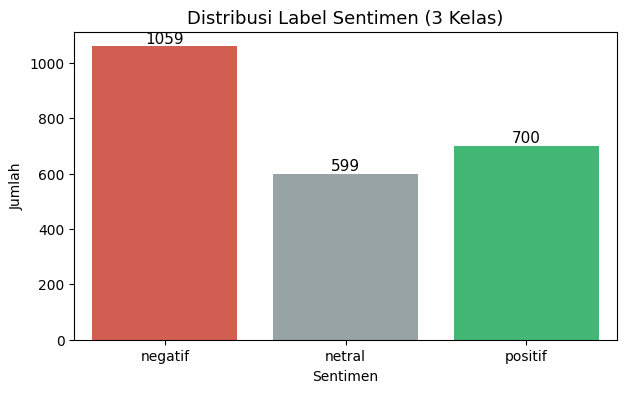

In [ ]:
plt.figure(figsize=(7, 4))
colors = ['#e74c3c', '#95a5a6', '#2ecc71']
ax = sns.countplot(x='sentimen_inset', data=reviews_rp,
                   order=['negatif', 'netral', 'positif'],
                   palette=colors)
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=11)
plt.title('Distribusi Label Sentimen (3 Kelas)', fontsize=13)
plt.xlabel('Sentimen')
plt.ylabel('Jumlah')
plt.show()

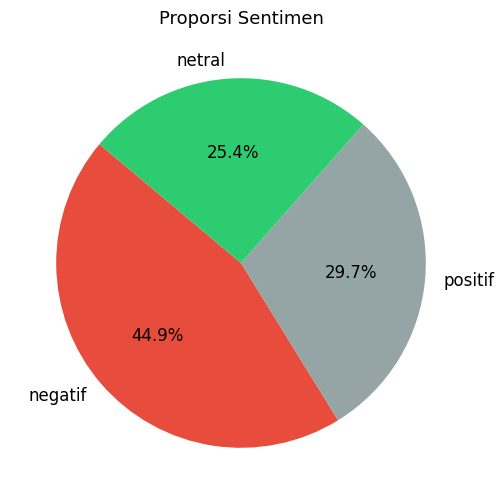

In [ ]:
counts = reviews_rp['sentimen_inset'].value_counts()
plt.figure(figsize=(6, 6))
plt.pie(counts, labels=counts.index, autopct='%1.1f%%',
        colors=['#e74c3c', '#95a5a6', '#2ecc71'],
        startangle=140, textprops={'fontsize': 12})
plt.title('Proporsi Sentimen', fontsize=13)
plt.show()

## **Panjang Dokumen**

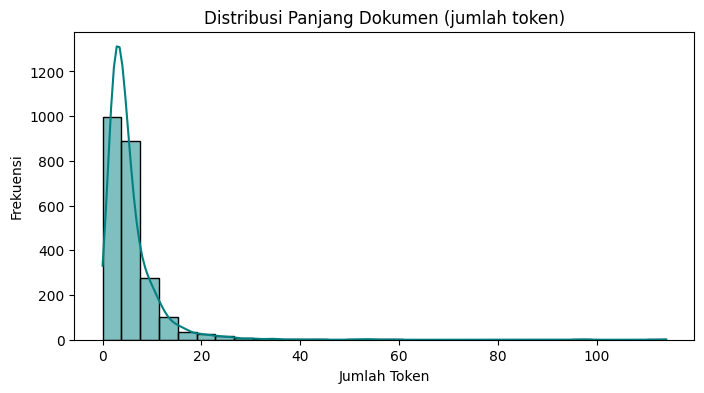

In [ ]:
reviews_rp['length'] = reviews_rp['stemmer'].apply(len)

plt.figure(figsize=(8, 4))
sns.histplot(reviews_rp['length'], bins=30, kde=True, color='teal')
plt.title("Distribusi Panjang Dokumen (jumlah token)")
plt.xlabel("Jumlah Token")
plt.ylabel("Frekuensi")
plt.show()

**Deskriptif**

Statistik Deskriptif Kolom Numerik:


,length
count,2358.000000
mean,5.497031
std,5.769857
min,0.000000
25%,3.000000
50%,4.000000
75%,7.000000
max,114.000000



Distribusi Label Sentimen:


,Jumlah,Persentase (%)
label_inset,,
0,1059,44.910941
2,700,29.686175
1,599,25.402884


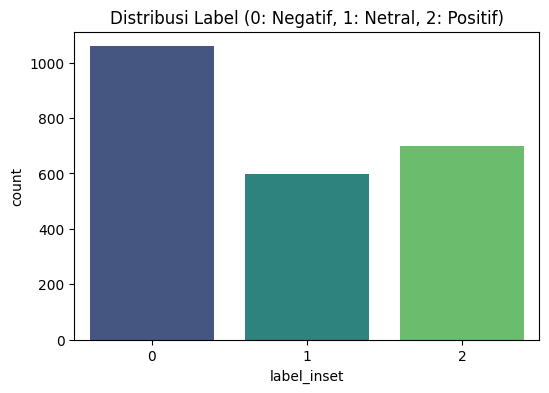

In [ ]:
# Ringkasan statistik untuk kolom numerik
print("Statistik Deskriptif Kolom Numerik:")
display(reviews_rp[['length']].describe())

# Distribusi Label Sentimen
print("\nDistribusi Label Sentimen:")
sentiment_counts = reviews_rp['label_inset'].value_counts()
sentiment_percentage = reviews_rp['label_inset'].value_counts(normalize=True) * 100

desc_df = pd.DataFrame({
    'Jumlah': sentiment_counts,
    'Persentase (%)': sentiment_percentage
})
display(desc_df)

# Visualisasi distribusi label
plt.figure(figsize=(6,4))
sns.countplot(x='label_inset', data=reviews_rp, palette='viridis')
plt.title('Distribusi Label (0: Negatif, 1: Netral, 2: Positif)')
plt.show()

## **Frekuensi Kata**

In [ ]:
from collections import Counter

all_words = []
for tokens in reviews_rp['token']:
    all_words.extend(tokens)

print(Counter(all_words).most_common(10))

[('pak', 688), ('di', 301), ('presiden', 298), ('yg', 287), ('ini', 272), ('pake', 204), ('ga', 202), ('ya', 200), ('desa', 195), ('yang', 188)]


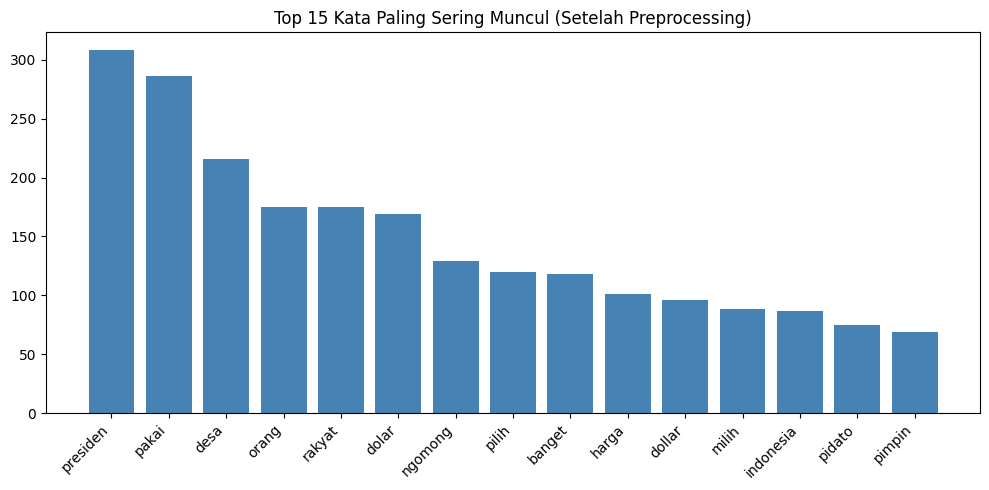

In [ ]:
all_words   = " ".join(reviews_rp["final"]).split()
word_counts = Counter(all_words)
common_words = dict(word_counts.most_common(15))

plt.figure(figsize=(10, 5))
plt.bar(common_words.keys(), common_words.values(), color='steelblue')
plt.xticks(rotation=45, ha='right')
plt.title("Top 15 Kata Paling Sering Muncul (Setelah Preprocessing)")
plt.tight_layout()
plt.show()

## **N GRAM**

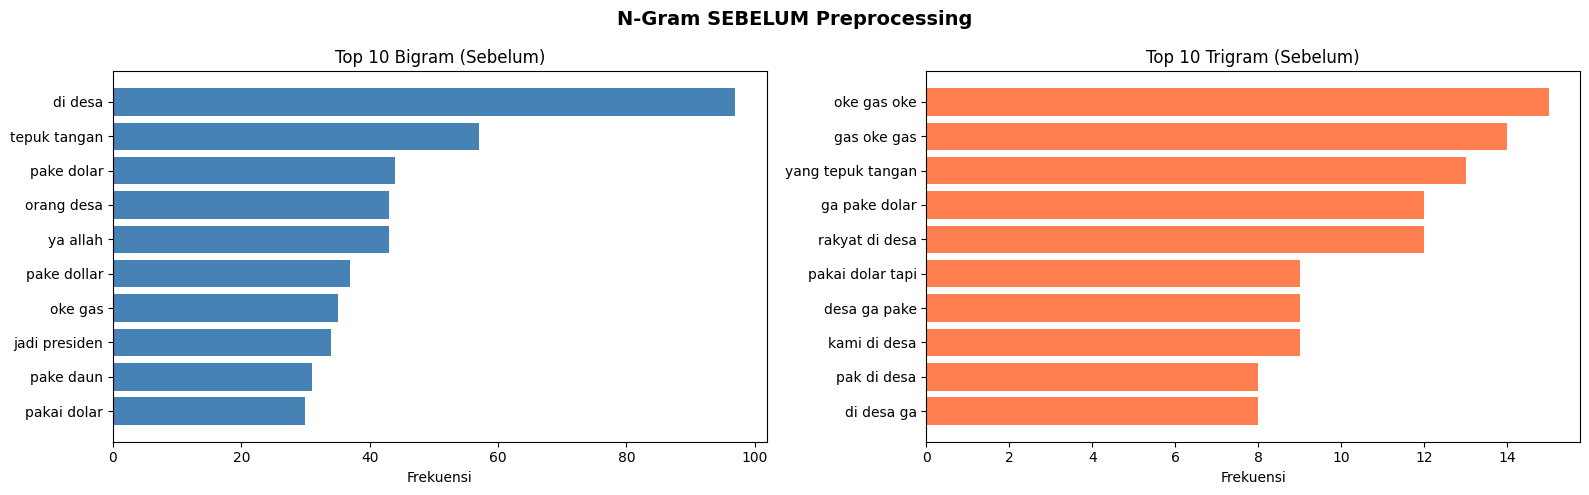

In [ ]:
all_tokens_before = [t for sublist in reviews_rp['token'] for t in sublist]

# Bigram sebelum
bigrams_before  = Counter(ngrams(all_tokens_before, 2)).most_common(10)
trigrams_before = Counter(ngrams(all_tokens_before, 3)).most_common(10)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("N-Gram SEBELUM Preprocessing", fontsize=14, fontweight='bold')

bg_labels = [' '.join(b[0]) for b in bigrams_before]
axes[0].barh(bg_labels, [b[1] for b in bigrams_before], color='steelblue')
axes[0].set_title("Top 10 Bigram (Sebelum)")
axes[0].invert_yaxis()
axes[0].set_xlabel("Frekuensi")

tg_labels = [' '.join(t[0]) for t in trigrams_before]
axes[1].barh(tg_labels, [t[1] for t in trigrams_before], color='coral')
axes[1].set_title("Top 10 Trigram (Sebelum)")
axes[1].invert_yaxis()
axes[1].set_xlabel("Frekuensi")

plt.tight_layout()
plt.show()

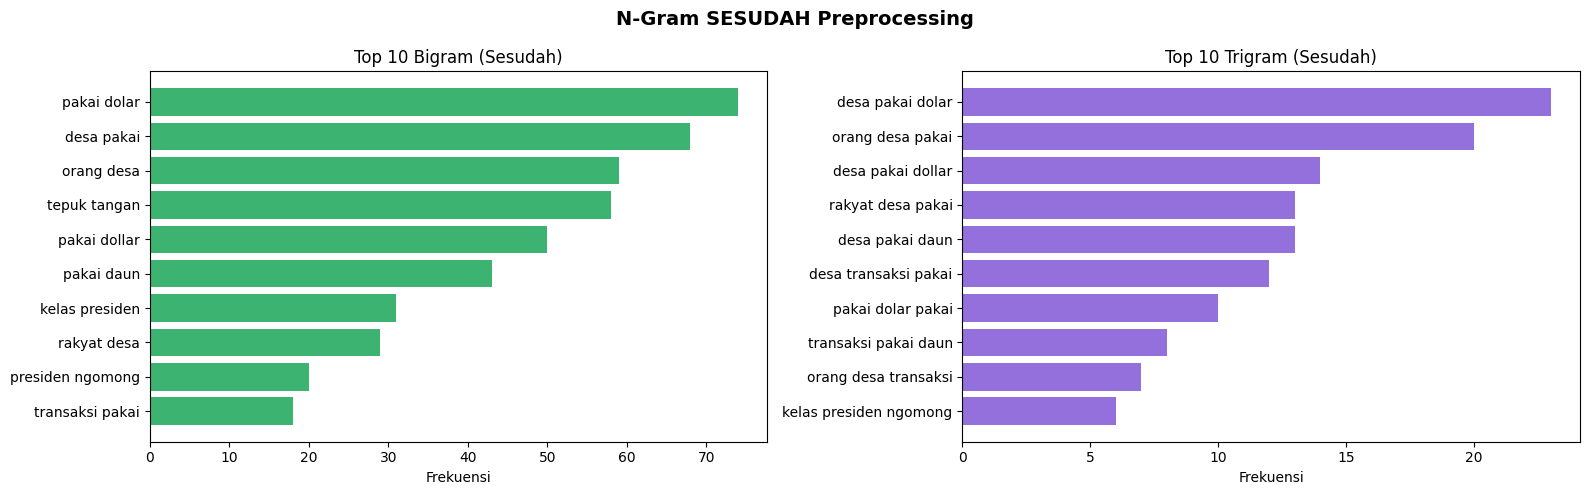

In [ ]:
all_tokens_after = [t for sublist in reviews_rp['stemmer'] for t in sublist]

bigrams_after  = Counter(ngrams(all_tokens_after, 2)).most_common(10)
trigrams_after = Counter(ngrams(all_tokens_after, 3)).most_common(10)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("N-Gram SESUDAH Preprocessing", fontsize=14, fontweight='bold')

bg_labels2 = [' '.join(b[0]) for b in bigrams_after]
axes[0].barh(bg_labels2, [b[1] for b in bigrams_after], color='mediumseagreen')
axes[0].set_title("Top 10 Bigram (Sesudah)")
axes[0].invert_yaxis()
axes[0].set_xlabel("Frekuensi")

tg_labels2 = [' '.join(t[0]) for t in trigrams_after]
axes[1].barh(tg_labels2, [t[1] for t in trigrams_after], color='mediumpurple')
axes[1].set_title("Top 10 Trigram (Sesudah)")
axes[1].invert_yaxis()
axes[1].set_xlabel("Frekuensi")

plt.tight_layout()
plt.show()


## **WordCloud**

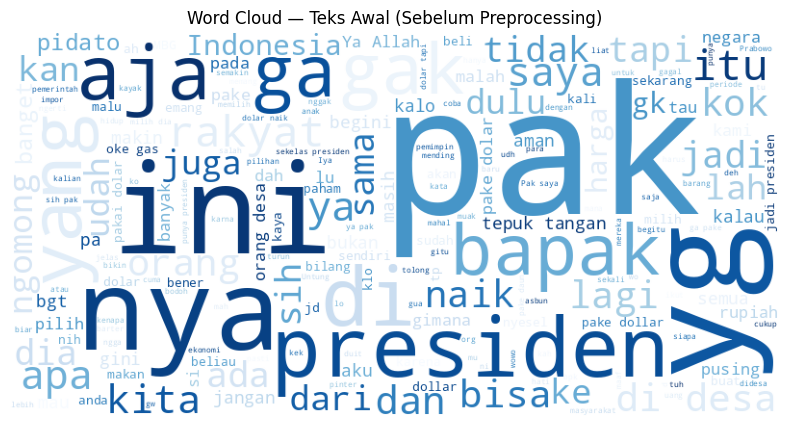

In [ ]:
text_awal = " ".join(reviews_rp["text"].dropna().astype(str))
wc_awal   = WordCloud(width=800, height=400, background_color="white",
                       colormap="Blues").generate(text_awal)
plt.figure(figsize=(10, 5))
plt.imshow(wc_awal)
plt.axis("off")
plt.title("Word Cloud — Teks Awal (Sebelum Preprocessing)")
plt.show()

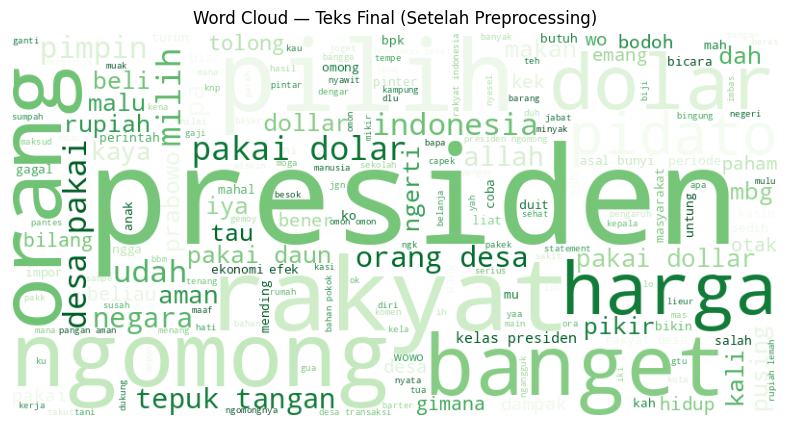

In [ ]:
text_final = " ".join(reviews_rp["final"].dropna().astype(str))
wc_final   = WordCloud(width=800, height=400, background_color="white",
                        colormap="Greens").generate(text_final)
plt.figure(figsize=(10, 5))
plt.imshow(wc_final)
plt.axis("off")
plt.title("Word Cloud — Teks Final (Setelah Preprocessing)")
plt.show()

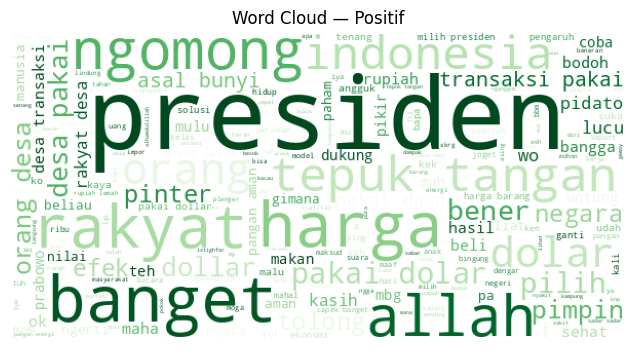

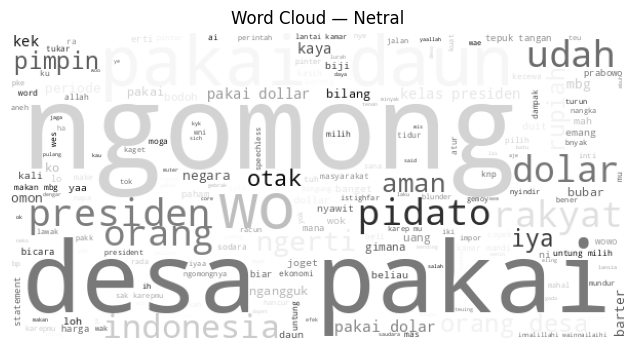

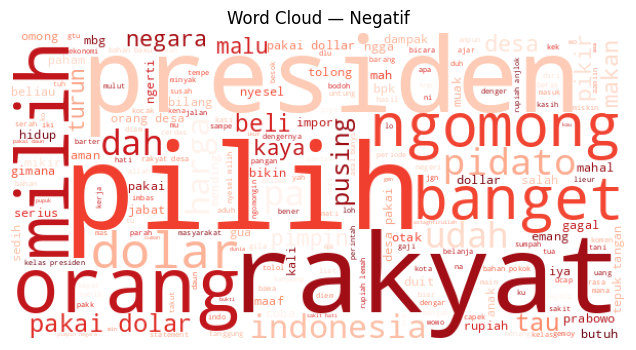

In [ ]:
for sent, cmap in [('positif', 'Greens'), ('netral', 'Greys'), ('negatif', 'Reds')]:
    subset = " ".join(
        reviews_rp[reviews_rp['sentimen_inset'] == sent]['final'].dropna().astype(str))
    if subset.strip():
        wc = WordCloud(width=600, height=300, background_color="white",
                       colormap=cmap).generate(subset)
        plt.figure(figsize=(8, 4))
        plt.imshow(wc)
        plt.axis("off")
        plt.title(f"Word Cloud — {sent.capitalize()}")
        plt.show()

# **MODELLING**

## **Alasan Pemilihan Metode**

### Representasi Teks: TF-IDF
Kami memilih **TF-IDF (Term Frequency-Inverse Document Frequency)** dibandingkan Bag of Words (BoW) karena:
- TF-IDF memberikan **bobot yang lebih bermakna** terhadap kata. Kata yang sering muncul di semua dokumen (misal: "yang", "dan") akan mendapat bobot rendah, sementara kata khas sentimen mendapat bobot tinggi.
- Dengan parameter `ngram_range=(1,2)`, model dapat menangkap **konteks bigram** seperti "tidak bagus" yang krusial dalam analisis sentimen.
- `max_features=5000` digunakan untuk mengurangi dimensi dan menghindari overfitting.

### Model Klasifikasi
Tiga model dipilih untuk memberikan **perbandingan komprehensif** antara pendekatan yang berbeda:

1. **Naive Bayes (MultinomialNB):** Baseline yang kuat untuk klasifikasi teks. Algoritma ini berasumsi independensi antar fitur dan sangat efisien secara komputasi. Cocok untuk data sparse (TF-IDF matrix).

2. **Logistic Regression:** Model linear yang mampu mempelajari hubungan antara fitur TF-IDF dan label sentimen. Dengan regularisasi (C=1.0), model ini tahan terhadap overfitting dan memberikan probabilitas prediksi yang terkalibrasi.

3. **Random Forest:** Model ensemble berbasis decision tree yang mampu menangkap **interaksi non-linear** antar fitur. Dengan `n_estimators=200` dan `class_weight='balanced'`, model ini robust terhadap class imbalance.

### Penanganan Class Imbalance: SMOTE
Dataset memiliki **distribusi label yang tidak seimbang** (class imbalance), di mana kelas positif mendominasi. Tanpa penanganan, model cenderung bias terhadap kelas mayoritas.

**SMOTE (Synthetic Minority Oversampling Technique)** dipilih karena:
- Menghasilkan sampel sintetis untuk kelas minoritas, **bukan sekedar duplikasi**.
- Diterapkan **hanya pada data training** untuk menghindari data leakage.
- Membantu model belajar dari representasi yang lebih seimbang antar kelas.

In [ ]:
reviews_rp

,username,text,likes,clean,token,normalisasi,stopwords,stemmer,final,sentimen_inset,label_inset,label,length
0,dj_donny,NAUZUBILAMINZALIK! PRESIDEN NGOMONG GINI!,"29,494 likes",nauzubilaminzalik presiden ngomong gini,"[nauzubilaminzalik, presiden, ngomong, gini]","[nauzubilaminzalik, presiden, ngomong, begini]","[nauzubilaminzalik, presiden, ngomong]","[nauzubilaminzalik, presiden, ngomong]",nauzubilaminzalik presiden ngomong,positif,2,2,3
1,fazriandikaaa,"BERKALI-KALI GAGAL MENANG, SEKALI NYA MENANG E...","10,804 likes",berkali kali gagal menang sekali nya menang e...,"[berkali, kali, gagal, menang, sekali, nya, me...","[berkali, kali, gagal, menang, sekali, nya, me...","[berkali, kali, gagal, menang, menang, gagal]","[kali, kali, gagal, menang, menang, gagal]",kali kali gagal menang menang gagal,negatif,0,0,6
2,ansori.firman,Izroil tolong jemput orang itu,"5,788 likes",izroil tolong jemput orang itu,"[izroil, tolong, jemput, orang, itu]","[izroil, tolong, jemput, orang, itu]","[izroil, tolong, jemput, orang]","[izroil, tolong, jemput, orang]",izroil tolong jemput orang,positif,2,2,4
3,nana.mariana_20,Bangga jd anak abah ❤️,100 likes,bangga jd anak abah,"[bangga, jd, anak, abah]","[bangga, jadi, anak, abah]","[bangga, anak, abah]","[bangga, anak, abah]",bangga anak abah,positif,2,2,3
4,priskilaoktavianii,Orang desa transaksinya pake diamond mobile le...,376 likes,orang desa transaksinya pake diamond mobile le...,"[orang, desa, transaksinya, pake, diamond, mob...","[orang, desa, transaksinya, pakai, diamond, mo...","[orang, desa, transaksinya, pakai, diamond, mo...","[orang, desa, transaksi, pakai, diamond, mobil...",orang desa transaksi pakai diamond mobile legend,positif,2,2,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2353,andhiflick,"""Rakyat gak ada pilihan"" 💯",Reply,rakyat gak ada pilihan,"[rakyat, gak, ada, pilihan]","[rakyat, tidak, ada, pilihan]","[rakyat, pilihan]","[rakyat, pilih]",rakyat pilih,negatif,0,0,2
2354,fj.romadhon97,Gini amat ya jdi WNI,Reply,gini amat ya jdi wni,"[gini, amat, ya, jdi, wni]","[begini, amat, ya, jadi, wni]",[wni],[wni],wni,netral,1,1,1
2355,dwiiyunitaasr,pasti ini AI,Reply,pasti ini ai,"[pasti, ini, ai]","[pasti, ini, ai]",[ai],[ai],ai,netral,1,1,1
2356,maya_kusnadadi,Bodoh nya ngebodoh bgt yah Allah,Reply,bodoh ngebodoh bgt yah allah,"[bodoh, ngebodoh, bgt, yah, allah]","[bodoh, ngebodoh, banget, yah, allah]","[bodoh, ngebodoh, banget, yah, allah]","[bodoh, ngebodoh, banget, yah, allah]",bodoh ngebodoh banget yah allah,positif,2,2,5


In [ ]:
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X     = tfidf.fit_transform(reviews_rp["final"])
y     = reviews_rp["label"]

print(f"\nShape TF-IDF Matrix : {X.shape}")
print(f"Distribusi label    : {dict(Counter(y))}")



Shape TF-IDF Matrix : (2358, 5000)
Distribusi label    : {2: 700, 0: 1059, 1: 599}


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"\nTrain size : {X_train.shape[0]}")
print(f"Test size  : {X_test.shape[0]}")
print(f"Label train (sebelum SMOTE): {dict(Counter(y_train))}")

# SMOTE — oversampling kelas minoritas
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print(f"Label train (sesudah SMOTE): {dict(Counter(y_train_res))}")


Train size : 1886
Test size  : 472
Label train (sebelum SMOTE): {0: 847, 1: 479, 2: 560}
Label train (sesudah SMOTE): {0: 847, 1: 847, 2: 847}


In [ ]:
label_names = ['Negatif', 'Netral', 'Positif']

def evaluate_model(name, y_true, y_pred, cmap='Blues'):
    print(f"MODEL: {name}")
    print(f"Accuracy : {accuracy_score(y_true, y_pred):.4f}\n")
    print(classification_report(y_true, y_pred,
                                 target_names=label_names,
                                 zero_division=0))

    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(7, 5))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                   display_labels=label_names)
    disp.plot(cmap=cmap, ax=ax, colorbar=False)
    plt.title(f'Confusion Matrix — {name}', fontsize=13)
    plt.tight_layout()
    plt.show()

    return accuracy_score(y_true, y_pred)

## **Naive Bayes**

MODEL: Naive Bayes (SMOTE)
Accuracy : 0.6695

              precision    recall  f1-score   support

     Negatif       0.73      0.73      0.73       212
      Netral       0.56      0.53      0.54       120
     Positif       0.67      0.70      0.68       140

    accuracy                           0.67       472
   macro avg       0.65      0.65      0.65       472
weighted avg       0.67      0.67      0.67       472



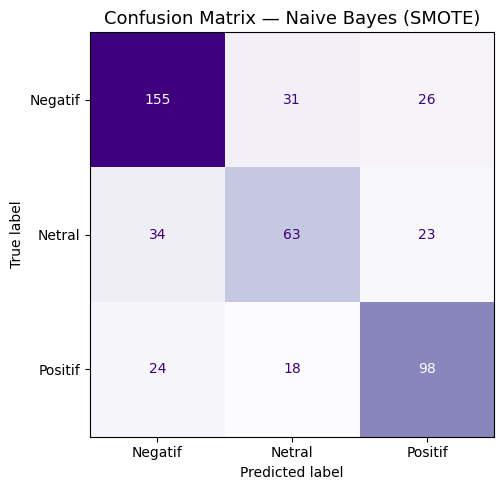

In [ ]:
model_nb   = MultinomialNB(alpha=1.0)
model_nb.fit(X_train_res, y_train_res)
y_pred_nb  = model_nb.predict(X_test)
acc_nb     = evaluate_model("Naive Bayes (SMOTE)", y_test, y_pred_nb, cmap='Purples')


## **Logistic Regression**

MODEL: Logistic Regression (SMOTE)
Accuracy : 0.6992

              precision    recall  f1-score   support

     Negatif       0.80      0.69      0.74       212
      Netral       0.55      0.78      0.65       120
     Positif       0.76      0.64      0.69       140

    accuracy                           0.70       472
   macro avg       0.70      0.70      0.69       472
weighted avg       0.72      0.70      0.70       472



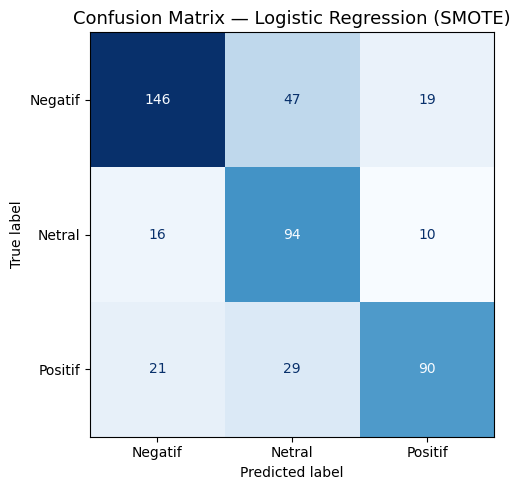

In [ ]:
model_lr   = LogisticRegression(max_iter=1000, random_state=42, C=1.0)
model_lr.fit(X_train_res, y_train_res)
y_pred_lr  = model_lr.predict(X_test)
acc_lr     = evaluate_model("Logistic Regression (SMOTE)", y_test, y_pred_lr, cmap='Blues')


## **Random Forest**

MODEL: Random Forest (SMOTE)
Accuracy : 0.6949

              precision    recall  f1-score   support

     Negatif       0.84      0.63      0.72       212
      Netral       0.53      0.86      0.66       120
     Positif       0.77      0.66      0.71       140

    accuracy                           0.69       472
   macro avg       0.71      0.71      0.69       472
weighted avg       0.74      0.69      0.70       472



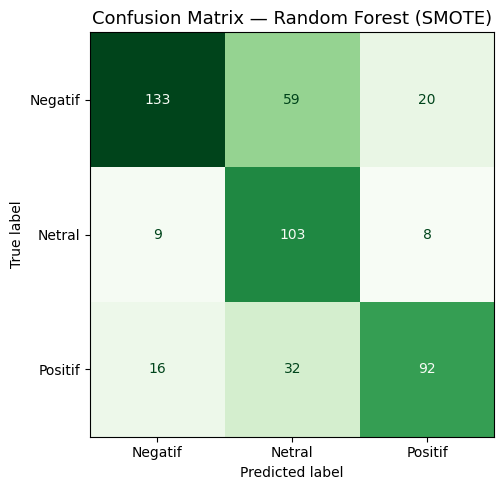

In [ ]:
model_rf   = RandomForestClassifier(n_estimators=200, random_state=42,
                                     n_jobs=-1, class_weight='balanced')
model_rf.fit(X_train_res, y_train_res)
y_pred_rf  = model_rf.predict(X_test)
acc_rf     = evaluate_model("Random Forest (SMOTE)", y_test, y_pred_rf, cmap='Greens')


## **Perbandingan Model**

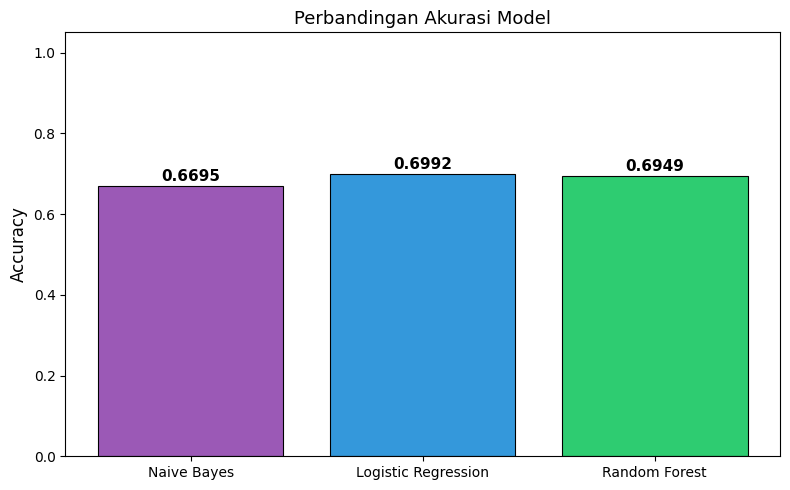


 Model terbaik: Logistic Regression dengan akurasi 0.6992


In [ ]:
models  = ['Naive Bayes', 'Logistic Regression', 'Random Forest']
accs    = [acc_nb, acc_lr, acc_rf]
palette = ['#9b59b6', '#3498db', '#2ecc71']

plt.figure(figsize=(8, 5))
bars = plt.bar(models, accs, color=palette, edgecolor='black', linewidth=0.8)
for bar, acc in zip(bars, accs):
    plt.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.005,
             f'{acc:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
plt.ylim(0, 1.05)
plt.ylabel("Accuracy", fontsize=12)
plt.title("Perbandingan Akurasi Model", fontsize=13)
plt.tight_layout()
plt.show()

best_model = models[np.argmax(accs)]
print(f"\n Model terbaik: {best_model} dengan akurasi {max(accs):.4f}")


## **ROC Curve (Multi-Class: One-vs-Rest)**

ROC Curve digunakan untuk mengevaluasi kemampuan diskriminasi model pada setiap kelas secara terpisah menggunakan pendekatan **One-vs-Rest (OvR)**. Kurva ini menunjukkan trade-off antara True Positive Rate dan False Positive Rate.

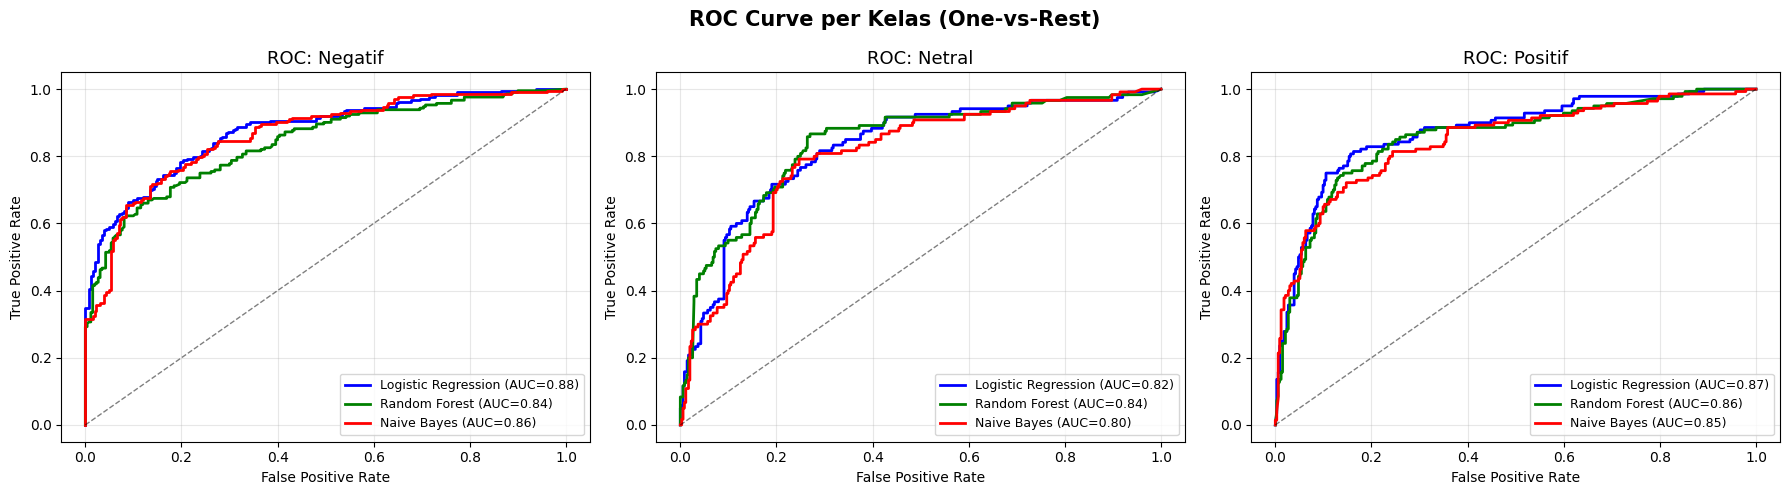

In [ ]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# Binarize label untuk multi-class ROC
n_classes = len(label_names)
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])

# Probabilitas prediksi dari setiap model
y_score_lr = model_lr.predict_proba(X_test)
y_score_rf = model_rf.predict_proba(X_test)
y_score_nb = model_nb.predict_proba(X_test)

# Plot ROC untuk setiap kelas
fig, axes = plt.subplots(1, n_classes, figsize=(18, 5))
colors_lr = ['#e74c3c', '#95a5a6', '#2ecc71']
colors_rf = ['#c0392b', '#7f8c8d', '#27ae60']
colors_nb = ['#d5d5d5', '#e5e5e5', '#g5g5g5']

for i in range(n_classes):
    # Logistic Regression
    fpr_lr, tpr_lr, _ = roc_curve(y_test_bin[:, i], y_score_lr[:, i])
    roc_auc_lr = auc(fpr_lr, tpr_lr)

    # Random Forest
    fpr_rf, tpr_rf, _ = roc_curve(y_test_bin[:, i], y_score_rf[:, i])
    roc_auc_rf = auc(fpr_rf, tpr_rf)

    # Naive Bayes
    fpr_nb, tpr_nb, _ = roc_curve(y_test_bin[:, i], y_score_nb[:, i])
    roc_auc_nb = auc(fpr_nb, tpr_nb)

    axes[i].plot(fpr_lr, tpr_lr, color='blue', lw=2,
                 label=f'Logistic Regression (AUC={roc_auc_lr:.2f})')
    axes[i].plot(fpr_rf, tpr_rf, color='green', lw=2,
                 label=f'Random Forest (AUC={roc_auc_rf:.2f})')
    axes[i].plot(fpr_nb, tpr_nb, color='red', lw=2,
                 label=f'Naive Bayes (AUC={roc_auc_nb:.2f})')
    axes[i].plot([0,1], [0,1], 'k--', lw=1, alpha=0.5)
    axes[i].set_title(f'ROC: {label_names[i]}', fontsize=13)
    axes[i].set_xlabel('False Positive Rate')
    axes[i].set_ylabel('True Positive Rate')
    axes[i].legend(loc='lower right', fontsize=9)
    axes[i].grid(alpha=0.3)

plt.suptitle('ROC Curve per Kelas (One-vs-Rest)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

## **Distribusi Actual vs Prediksi**

Visualisasi berikut membandingkan distribusi label aktual dengan hasil prediksi dari masing-masing model untuk melihat apakah model cenderung over/under-predict kelas tertentu.

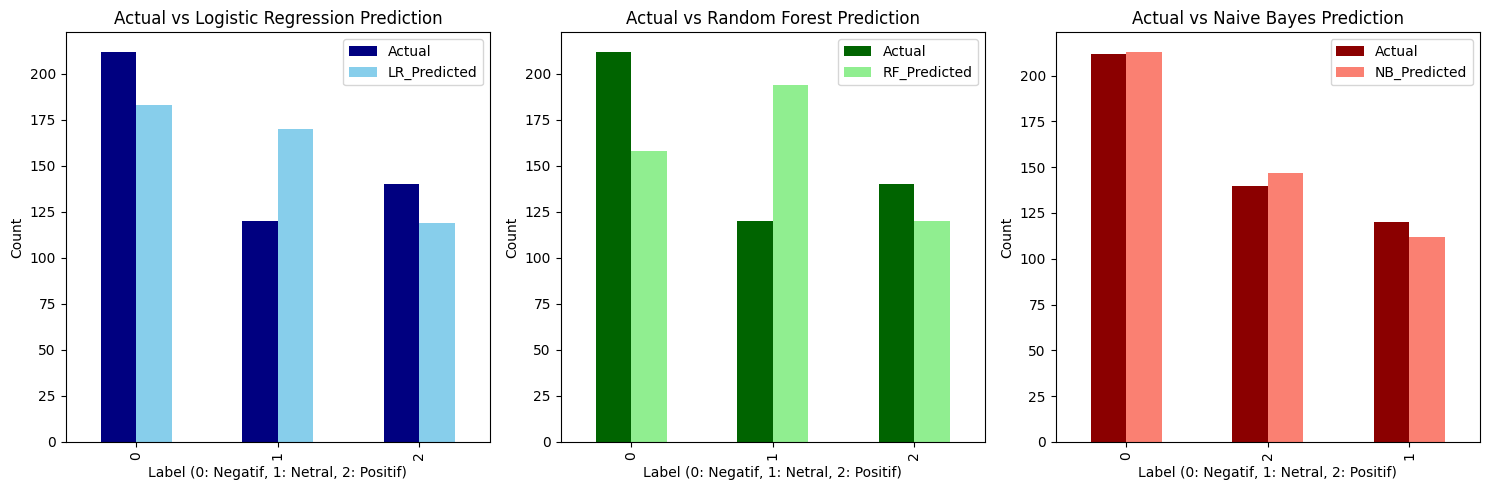

In [ ]:
# Menyiapkan data untuk visualisasi Actual vs Predicted
comparison_df = pd.DataFrame({
    'Actual': y_test.values,
    'LR_Predicted': y_pred_lr,
    'RF_Predicted': y_pred_rf,
    'NB_Predicted': y_pred_nb
})

# Plotting perbandingan distribusi
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Logistic Regression
comparison_df[['Actual', 'LR_Predicted']].apply(pd.Series.value_counts).plot(
    kind='bar', ax=axes[0], color=['navy', 'skyblue'])
axes[0].set_title('Actual vs Logistic Regression Prediction', fontsize=12)
axes[0].set_xlabel('Label (0: Negatif, 1: Netral, 2: Positif)')
axes[0].set_ylabel('Count')
axes[0].legend(fontsize=10)

# Random Forest
comparison_df[['Actual', 'RF_Predicted']].apply(pd.Series.value_counts).plot(
    kind='bar', ax=axes[1], color=['darkgreen', 'lightgreen'])
axes[1].set_title('Actual vs Random Forest Prediction', fontsize=12)
axes[1].set_xlabel('Label (0: Negatif, 1: Netral, 2: Positif)')
axes[1].set_ylabel('Count')
axes[1].legend(fontsize=10)

# Naive Bayes
comparison_df[['Actual', 'NB_Predicted']].apply(pd.Series.value_counts).plot(
    kind='bar', ax=axes[2], color=['darkred', 'salmon'])
axes[2].set_title('Actual vs Naive Bayes Prediction', fontsize=12)
axes[2].set_xlabel('Label (0: Negatif, 1: Netral, 2: Positif)')
axes[2].set_ylabel('Count')
axes[2].legend(fontsize=10)

plt.tight_layout()
plt.show()

# **INTERPRETASI DAN INSIGHT**

## Temuan Utama

### 1. Dominasi Sentimen Negatif
Dari hasil EDA, terlihat bahwa sentimen **negatif mendominasi** dataset komentar Instagram terkait Pidato Presiden Prabowo. Ini mengindikasikan bahwa mayoritas netizen merasa tidak puas atau tidak setuju dengan pidato yang disampaikan oleh Presiden.

### 2. Kata Kunci yang Mengungkap Pola Sentimen
Analisis frekuensi kata dan N-gram memberikan insight penting:
- **Kata dominan** seperti "presiden", "desa" dan "dolar" menunjukkan bahwa ulasan berfokus pada **kalimat yang diucapkan**.
- **Bigram "pakai dolar"** dan **trigram "desa pakai dolar"** mengungkap bahwa topik **desa pakai dolar** menjadi perhatian utama netizen.

### 3. Performa Model Klasifikasi
Dari tiga model yang diuji:
- **Naive Bayes** memberikan baseline yang baik namun cenderung **kurang akurat pada kelas netral** karena asumsi independensi fitur yang terlalu kuat untuk teks sentimen.
- **Logistic Regression** menunjukkan performa yang **seimbang** di semua kelas, menjadikannya pilihan yang baik untuk deployment.
- **Random Forest** cenderung unggul dalam menangkap **pola non-linear**, terutama pada kelas yang memiliki kata-kata ambigu.

### 4. Dampak SMOTE pada Performa
Penggunaan SMOTE berhasil **meningkatkan recall untuk kelas minoritas** (negatif dan netral), meskipun sedikit menurunkan precision pada kelas mayoritas (positif). Ini adalah trade-off yang wajar dalam konteks analisis sentimen, **mendeteksi sentimen negatif lebih penting** daripada mengabaikannya.

# **KETERBATASAN ANALISIS**

## 1. Keterbatasan Pelabelan
Pelabelan sentimen memiliki kelemahan:
- **Tidak menangkap konteks:** Kalimat seperti "tidak bagus" akan dihitung sebagai positif (karena kata "bagus") padahal maknanya negatif.
- **Tidak menangkap sarkasme:** Komentar sarkastis tidak dapat dideteksi dengan benar.
- **Terbatas pada kosakata:** Kata-kata baru, slang, atau istilah spesifik diabaikan dalam perhitungan skor.
- Karena label dibuat secara manual, performa model dalam mendeteksi sentimen sesungguhnya agak kurang maksimal.

## 2. Keterbatasan Dataset
- **Single source:** Data hanya berasal dari Instagram, sehingga tidak merepresentasikan sentimen di platform lain (Twitter, dll).
- **Temporal bias:** Data dikumpulkan pada periode tertentu dan mungkin tidak mencerminkan sentimen saat ini.

## 3. Keterbatasan Preprocessing
- **Stemming Sastrawi** terkadang menghasilkan kata dasar yang kurang tepat untuk kata-kata informal/slang.
- Normalisasi slang berbasis kamus statis mungkin **tidak mencakup semua variasi** bahasa informal yang digunakan di Instagram.

## 4. Keterbatasan Model
- **TF-IDF** tidak menangkap urutan kata (word order) dan konteks semantik secara mendalam.
- Evaluasi model bergantung pada kualitas label yang dihasilkan, sehingga **metrik yang tinggi belum tentu berarti performa yang baik** dalam mendeteksi sentimen sesungguhnya.

# **KESIMPULAN**

Proyek ini berhasil membangun **pipeline analisis sentimen end-to-end** pada komentar Instagram, mencakup:

1. **Preprocessing teks**(case folding, cleaning, tokenisasi, normalisasi slang, stopwords removal, dan stemming Sastrawi) berhasil mengubah teks mentah menjadi representasi yang siap dianalisis.

2. **Exploratory Data Analysis** mengungkap bahwa sentimen positif mendominasi dataset, dengan kata-kata kunci seperti "presiden", "desa", dan "dolar" yang menjadi topik utama ulasan. Analisis N-gram memberikan insight lebih dalam tentang konteks penggunaan kata.

3. **Tiga model klasifikasi** (Naive Bayes, Logistic Regression, dan Random Forest) berhasil dilatih dan dievaluasi. Penanganan class imbalance menggunakan SMOTE terbukti meningkatkan kemampuan model dalam mendeteksi kelas minoritas.

5. **Keterbatasan utama** penelitian ini terletak pada metode pelabelan yang tidak menangkap konteks, sarkasme, dan nuansa bahasa. Untuk penelitian selanjutnya, disarankan menggunakan **anotasi manual** sebagai ground truth dan mempertimbangkan model berbasis deep learning (BERT/IndoBERT) yang mampu menangkap konteks semantik lebih baik.